### Import

In [173]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

## Show img

### Load Img

In [174]:
slika = plt.imread('images/forest_horison.jpg')[:, :, :3]
slika = (slika).mean(2)

In [175]:
weights = [0.2989, 0.5870, 0.1140]
slika_gray = np.dot(slika[..., :3], weights)

### Apply Gaussian filter

In [176]:
sigma = 20.0
velikost_jedra = int(3*sigma)
# koordinate jedra po x dimenziji
x = np.arange(-velikost_jedra, velikost_jedra+1)
# koordinate jedra v obeh dimenzijah v 2d matrikah
X, Y = np.meshgrid(x, x)
jedro_tocke = np.array([X.ravel(), Y.ravel()]) # 2 x P
C = np.eye(2)*1/sigma**2

jedro_gauss = np.exp(-1*(jedro_tocke.T.dot(C)*jedro_tocke.T).sum(1)).reshape(X.shape)

slika_conv_gaussian = ndimage.convolve(slika, jedro_gauss, mode='constant', cval=0.0)

### Apply Sobel filter 
### Make magnitude

In [177]:
jedro_sobel_dx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
jedro_sobel_dy = np.array([
    [1,  2,  1],
    [0,  0,  0],
    [-1, -2, -1]
])

slika_dx = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dx, mode='constant', cval=0.0)
slika_dy = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dy, mode='constant', cval=0.0)
# slika_dx_and_dy = ndimage.convolve(slika_dx, jedro_sobel_dy, mode='constant', cval=0.0)
#"""
slika_rob_mag = (slika_dx**2 + slika_dy**2)**0.5 # samo pitagorov izrek
# slika_rob_smer = np.arctan2(slika_dy, slika_dx)
slika_rob_smer = np.arctan2(slika_dy, slika_dx)

# Apply Sobel filters to the image
slika_sobel_dx = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dx, mode='constant', cval=0.0)
slika_sobel_dy = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dy, mode='constant', cval=0.0)

# Compute the magnitude of the gradient
slika_sobel = np.hypot(slika_sobel_dx, slika_sobel_dy)

# Normalize the result
slika_sobel = (slika_sobel / slika_sobel.max()) * 255  # Scale to 0-255

# Convert to unsigned 8-bit integer type for proper image representation
slika_sobel = slika_sobel.astype(np.uint8)

### Correct edges

In [178]:
f=np.zeros((31, 31))
f[0, 0] = 1

slika_filt = ndimage.convolve(slika_sobel, f, mode='constant', cval=0)

### Make histogram
#### Apply magnitude to histogram as weights

In [179]:
# razdelimo histogram na 16 predalckov med vrednostmi -pi, pi
hist_bins = np.linspace(-np.pi, np.pi, 17)
# razdelimo piksle v predalcke po kotu roba, pomnozeno z weightom magnitude ki nam pove kak mocn je rob
hist_smeri_x, hist_smeri_y = np.histogram(slika_rob_smer, bins=hist_bins, weights=slika_rob_mag)

# Find the maximum value on the y-axis (histogram counts)
max_y = np.max(hist_smeri_x)

# Find the index of the maximum value
max_y_index = np.argmax(hist_smeri_x)

# Find the corresponding bin edge (x-axis)
max_x = hist_bins[max_y_index]

# Find the center of the bin with the highest count
max_bin_center = (hist_bins[max_y_index] + hist_bins[max_y_index + 1]) / 2

# Convert the bin center value from radians to degrees
max_bin_degrees = np.degrees(max_x)

## Show histogram and filtered image
## Print out angle

Maximum value on the x-axis (bin edge): 1.5707963267948966
Maximum value on the y-axis: 841857444.8916712
Maximum bin center value in radians: 1.5707963267948966
Maximum bin center value in degrees: 90.0


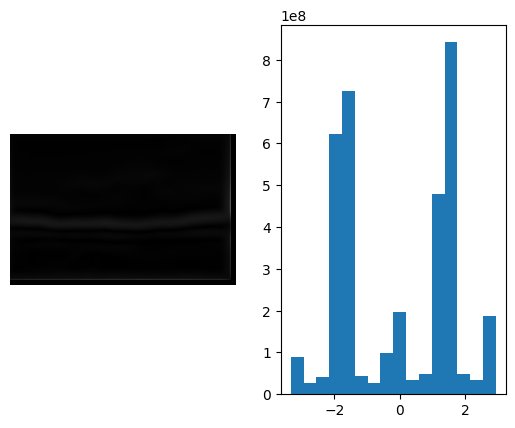

In [180]:
print(f"Maximum value on the x-axis (bin edge): {max_x}")
print(f"Maximum value on the y-axis: {max_y}")
print(f"Maximum bin center value in radians: {max_x}")
print(f"Maximum bin center value in degrees: {max_bin_degrees}")


#max_y = x[np.where(hist_smeri_y == hist_smeri_y.max())]
#print(f"Maximum: {hist_bins[max_y]}")


# Plot the image and histogram
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(slika_filt, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
# 16 bins, count is height, width is the difference between two edges
plt.bar(hist_bins[:-1], hist_smeri_x, width=hist_bins[1] - hist_bins[0])
plt.show()

#### Old show graph code

In [ ]:
"""
# Display the original and the blurred image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original img')
plt.imshow(slika, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Filtered img')
plt.imshow(slika_sobel, cmap='gray')
plt.axis('off')

plt.show()
"""